# Sanskrit OCR Engine

**Pipeline**: Preprocessing → OCR → Post-processing → Training → Testing → Evaluation

---

## Setup: Import Libraries

In [1]:
# Core Libraries
import os, re, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Utilities
from tqdm import tqdm
import unicodedata
from collections import OrderedDict

warnings.filterwarnings('ignore')


---
# STEP 1: PREPROCESSING
**Goal**: Clean images, remove noise, segment lines

## Implementation: Preprocessing Module

In [2]:
class ImagePreprocessor:
    """
    Comprehensive preprocessing module for Sanskrit document images.
    Handles grayscale conversion, noise reduction, binarization, skew correction,
    and contrast enhancement.
    """
    
    def __init__(self):
        self.processed_image = None
        self.original_image = None
        
    def load_image(self, image_path):
        """Load image from file path."""
        self.original_image = cv2.imread(image_path)
        if self.original_image is None:
            raise ValueError(f"Could not load image from {image_path}")
        return self.original_image
    
    def convert_to_grayscale(self, image):
        """Convert RGB image to grayscale using luminance formula."""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        return gray
    
    def reduce_noise(self, image, method='bilateral'):
        """
        Apply noise reduction filters.
        Methods: 'gaussian', 'bilateral', 'median'
        """
        if method == 'gaussian':
            denoised = cv2.GaussianBlur(image, (5, 5), 0)
        elif method == 'bilateral':
            # Edge-preserving filter - crucial for Devanagari ligatures
            denoised = cv2.bilateralFilter(image, 9, 75, 75)
        elif method == 'median':
            denoised = cv2.medianBlur(image, 5)
        else:
            denoised = image
        return denoised
    
    def binarize(self, image, method='adaptive'):
        """
        Convert grayscale to binary using various thresholding methods.
        """
        if method == 'otsu':
            _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        elif method == 'adaptive':
            # Adaptive thresholding - handles non-uniform illumination
            binary = cv2.adaptiveThreshold(
                image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                cv2.THRESH_BINARY, 11, 2
            )
        else:
            _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
        return binary
    
    def deskew(self, image):
        """
        Correct skew in scanned documents.
        Uses Hough transform to detect dominant angle.
        """
        # Calculate skew angle
        coords = np.column_stack(np.where(image < 128))
        if len(coords) == 0:
            return image, 0
        
        angle = cv2.minAreaRect(coords)[-1]
        
        # Adjust angle
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        
        # Rotate image
        (h, w) = image.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(
            image, M, (w, h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REPLICATE
        )
        
        return rotated, angle
    
    def enhance_contrast(self, image):
        """
        Enhance contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization).
        Particularly useful for degraded manuscripts.
        """
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(image)
        return enhanced
    
    def preprocess_pipeline(self, image_path, visualize=False):
        """
        Complete preprocessing pipeline.
        
        Steps:
        1. Load image
        2. Convert to grayscale
        3. Enhance contrast
        4. Reduce noise
        5. Deskew
        6. Binarize
        
        Args:
            image_path: path to input image
            visualize: if True, displays intermediate results
            
        Returns:
            binary: final preprocessed binary image
        """
        print("\n" + "="*80)
        print(" "*25 + "PREPROCESSING")
        print("="*80)
        
        # Step 1: Load
        print("\n1. Loading image...")
        self.original_image = self.load_image(image_path)
        print(f"   Original size: {self.original_image.shape}")
        
        # Step 2: Grayscale
        print("2. Converting to grayscale...")
        gray = self.convert_to_grayscale(self.original_image)
        
        # Step 3: Enhance contrast
        print("3. Enhancing contrast (CLAHE)...")
        enhanced = self.enhance_contrast(gray)
        
        # Step 4: Noise reduction
        print("4. Reducing noise (bilateral filter)...")
        denoised = self.reduce_noise(enhanced, method='bilateral')
        
        # Step 5: Deskew
        print("5. Correcting skew...")
        deskewed, skew_angle = self.deskew(denoised)
        print(f"   Skew angle corrected: {skew_angle:.2f}°")
        
        # Step 6: Binarization
        print("6. Binarizing (adaptive threshold)...")
        binary = self.binarize(deskewed, method='adaptive')
        
        self.processed_image = binary
        
        if visualize:
            self.intermediate_results = {
                "original": self.original_image,
                "gray": gray,
                "enhanced": enhanced,
                "denoised": denoised,
                "deskewed": deskewed,
                "binary": binary,
                "skew_angle": skew_angle
            }
        print("✓ Preprocessing complete!\n")
        return binary


# Initialize preprocessor
preprocessor = ImagePreprocessor()
print("Preprocessor initialized successfully!")

Preprocessor initialized successfully!


## Implementation: Line Segmentation Module

In [3]:
class LineSegmenter:
    """
    Automatic line segmentation for Sanskrit/Devanagari text
    using horizontal projection profiles.
    """

    def __init__(self, min_line_height=20, min_gap=5):
        self.min_line_height = min_line_height
        self.min_gap = min_gap

    def horizontal_projection(self, binary_image):
        """Calculate horizontal projection profile (sum of white pixels per row)."""
        return np.sum(binary_image == 0, axis=1)  # Count black pixels

    def detect_line_boundaries(self, projection):
        """
        Detect line boundaries from projection profile.
        Returns list of (start_row, end_row) tuples.
        """
        in_line = False
        start_row = 0
        boundaries = []

        for i, count in enumerate(projection):
            if count > 0 and not in_line:
                # Start of a line
                start_row = i
                in_line = True
            elif count == 0 and in_line:
                # End of a line
                if i - start_row >= self.min_line_height:
                    boundaries.append((start_row, i))
                in_line = False

        # Handle case where line extends to bottom
        if in_line and len(projection) - start_row >= self.min_line_height:
            boundaries.append((start_row, len(projection)))

        return boundaries

    def extract_lines(self, binary_image, boundaries):
        """Extract individual line images from boundaries."""
        lines = []
        for idx, (start, end) in enumerate(boundaries):
            line_img = binary_image[start:end, :]
            lines.append({
                'image': line_img,
                'line_number': idx + 1,
                'y_start': start,
                'y_end': end,
                'height': end - start,
                'width': line_img.shape[1]
            })
        return lines

    def segment_lines(self, binary_image, normalize=True, target_height=32):
        """
        Complete line segmentation pipeline.
        
        Args:
            binary_image: preprocessed binary image
            normalize: whether to normalize line heights
            target_height: target height for normalized lines
            
        Returns:
            list of line dictionaries with images and metadata
        """
        print("\n" + "="*80)
        print(" "*25 + "LINE SEGMENTATION")
        print("="*80)
        
        # Calculate projection
        print("\n1. Calculating horizontal projection profile...")
        projection = self.horizontal_projection(binary_image)
        
        # Detect boundaries
        print("2. Detecting line boundaries...")
        boundaries = self.detect_line_boundaries(projection)
        print(f"   Found {len(boundaries)} text lines")
        
        # Extract lines
        print("3. Extracting individual lines...")
        lines = self.extract_lines(binary_image, boundaries)
        
        # Normalize heights if requested
        if normalize:
            print(f"4. Normalizing line heights to {target_height}px...")
            for line in lines:
                h, w = line['image'].shape
                aspect_ratio = w / h
                new_width = int(target_height * aspect_ratio)
                
                resized = cv2.resize(
                    line['image'],
                    (new_width, target_height),
                    interpolation=cv2.INTER_AREA
                )
                line['image'] = resized
                line['normalized_height'] = target_height
                line['normalized_width'] = new_width
        
        print(f"✓ Line segmentation complete! Extracted {len(lines)} lines\n")
        return lines

    def visualize_projection(self, image, projection, boundaries):
        """Visualize horizontal projection profile with detected boundaries."""
        plt.figure(figsize=(15, 8))
        
        plt.subplot(2, 1, 1)
        plt.imshow(image, cmap='gray')
        for (start, end) in boundaries:
            plt.axhline(y=start, color='g', linewidth=2, alpha=0.7)
            plt.axhline(y=end, color='r', linewidth=2, alpha=0.7)
        plt.title("Binary Image with Detected Line Boundaries")
        plt.axis('off')
        
        plt.subplot(2, 1, 2)
        plt.barh(range(len(projection)), projection, color='blue', alpha=0.6)
        for start, end in boundaries:
            plt.axvline(x=start, color='green', linestyle='--', alpha=0.6)
            plt.axvline(x=end, color='red', linestyle='--', alpha=0.6)
        plt.title("Horizontal Projection Profile")
        plt.show()

    def visualize_lines(self, image, boundaries):
        """Draw detected line boxes on image."""
        vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        for (start, end) in boundaries:
            cv2.rectangle(vis, (0, start), (image.shape[1], end), (0, 255, 0), 2)
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title("Detected Lines")
        plt.show()


# Initialize segmenter
segmenter = LineSegmenter(min_line_height=20, min_gap=5)
print("Line Segmenter initialized successfully!")

# -----------------------------------------------------------------------------
# Dataset-level line segmentation and preprocessing utilities
# These helper functions apply the existing `segmenter` to the entire dataset,
# save segmented line crops, and optionally run simple preprocessing on them.
# -----------------------------------------------------------------------------
from tqdm import tqdm
import glob

def apply_line_segmentation_to_dataset(dataset_root, output_dir, sample_n=None, exts=('png','jpg','jpeg','tif','tiff')):
    """Walk `dataset_root`, find image files, run the `segmenter` on each page,
    save line crops under `output_dir/<page_basename>/line_XXX.png`.
    If `sample_n` is provided, only process the first `sample_n` pages (useful for quick checks).
    Returns: (num_pages_processed, total_lines_extracted)
    """
    os.makedirs(output_dir, exist_ok=True)
    # Collect image files
    image_files = []
    for root, _, files in os.walk(dataset_root):
        for f in files:
            if f.split('.')[-1].lower() in exts:
                image_files.append(os.path.join(root, f))

    image_files = sorted(image_files)
    if sample_n is not None:
        image_files = image_files[:sample_n]

    total_pages = len(image_files)
    total_lines = 0

    print(f"Processing {total_pages} pages from: {dataset_root}")
    for page_path in tqdm(image_files, desc="Segmenting pages"):
        try:
            img = cv2.imread(page_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  Skipping unreadable file: {page_path}")
                continue

            # Preprocessing for segmentation: denoise + binarize
            blurred = cv2.GaussianBlur(img, (3, 3), 0)
            _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # Ensure binary has text as black (0). If text appears white, invert.
            # Count black pixels: if too few, invert the image
            black_ratio = np.sum(binary == 0) / (binary.shape[0] * binary.shape[1])
            if black_ratio < 0.01:
                binary = 255 - binary

            # Segment lines using the existing segmenter (normalization to IMG_HEIGHT)
            lines = segmenter.segment_lines(binary, normalize=True, target_height=IMG_HEIGHT)

            base = os.path.splitext(os.path.basename(page_path))[0]
            out_page_dir = os.path.join(output_dir, base)
            os.makedirs(out_page_dir, exist_ok=True)

            for i, line in enumerate(lines, start=1):
                out_path = os.path.join(out_page_dir, f"line_{i:03d}.png")
                # line['image'] is already a numpy array (grayscale/binary or normalized), write it
                cv2.imwrite(out_path, line['image'])

            total_lines += len(lines)
        except Exception as e:
            print(f"  Error processing {page_path}: {e}")

    print(f"Done. Pages processed: {total_pages}. Total lines extracted: {total_lines}")
    return total_pages, total_lines

def preprocess_segmented_lines(segmented_root, preproc_root, img_height=IMG_HEIGHT, binarize=True):
    """Apply a lightweight preprocessing pipeline to every segmented line image.
    - binarize (optional), resize to `img_height` (preserve aspect ratio), and save into `preproc_root`
    Returns: number of files processed
    """
    os.makedirs(preproc_root, exist_ok=True)
    processed = 0

    for root, _, files in os.walk(segmented_root):
        rel_dir = os.path.relpath(root, segmented_root)
        out_dir = os.path.join(preproc_root, rel_dir)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            if not f.lower().endswith('.png'):
                continue
            in_path = os.path.join(root, f)
            try:
                img = cv2.imread(in_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                if binarize:
                    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

                h, w = img.shape
                aspect = w / float(h)
                new_w = max(1, int(img_height * aspect))
                resized = cv2.resize(img, (new_w, img_height), interpolation=cv2.INTER_AREA)

                out_path = os.path.join(out_dir, f)
                cv2.imwrite(out_path, resized)
                processed += 1
            except Exception as e:
                print(f"  Failed preprocess {in_path}: {e}")

    print(f"Preprocessing complete. Files processed: {processed}")
    return processed

def show_sample_segmentations(dataset_root, segmented_root, n_pages=3, max_lines_per_page=6):
    """Display `n_pages` original pages and a grid of segmented lines for quick verification."""
    import random
    pages = []
    for root, _, files in os.walk(segmented_root):
        if files:
            pages.append((root, files))
    if len(pages) == 0:
        print("No segmented pages found in segmented_root. Run apply_line_segmentation_to_dataset first.")
        return

    chosen = random.sample(pages, min(n_pages, len(pages)))
    for page_dir, files in chosen:
        # show original page if available (try to find matching original by basename)
        base = os.path.basename(page_dir)
        # Try to find original in dataset_root with same basename
        orig_candidates = []
        for root, _, fs in os.walk(dataset_root):
            for f in fs:
                if os.path.splitext(f)[0] == base:
                    orig_candidates.append(os.path.join(root, f))
        orig_path = orig_candidates[0] if orig_candidates else None

        if orig_path is not None:
            orig = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
            plt.figure(figsize=(10, 3))
            plt.imshow(orig, cmap='gray')
            plt.title(f'Original page: {base}')
            plt.axis('off')
            plt.show()

        # Show up to max_lines_per_page line crops
        show_files = sorted(files)[:max_lines_per_page]
        cols = min(4, len(show_files))
        rows = int(np.ceil(len(show_files) / float(cols)))
        plt.figure(figsize=(cols * 3, rows * 1.8))
        for i, fname in enumerate(show_files):
            img = cv2.imread(os.path.join(page_dir, fname), cv2.IMREAD_GRAYSCALE)
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(fname)
            plt.axis('off')
        plt.suptitle(f'Line crops for page: {base}')
        plt.show()

# Quick demo: run segmentation+preprocessing on a small sample (change paths as desired)
# NOTE: This is a lightweight check. For full dataset processing, call the functions with sample_n=None.
def run_quick_segmentation_preview(sample_n=10):
    preview_dir = os.path.join(DATASET_ROOT, 'segmented_preview')
    preproc_dir = os.path.join(DATASET_ROOT, 'segmented_preproc_preview')
    pages, lines = apply_line_segmentation_to_dataset(DATASET_ROOT, preview_dir, sample_n=sample_n)
    print(f'Preview segmentation: pages={pages}, lines={lines}')
    processed = preprocess_segmented_lines(preview_dir, preproc_dir, img_height=IMG_HEIGHT)
    print(f'Preprocessed {processed} segmented lines into: {preproc_dir}')
    show_sample_segmentations(DATASET_ROOT, preview_dir, n_pages=3, max_lines_per_page=8)

# End of dataset-level utilities
# -----------------------------------------------------------------------------
# To run a quick preview over a small set of pages, uncomment and call the helper below.
# Example: run_quick_segmentation_preview(sample_n=10)
# Note: this will create two folders under `DATASET_ROOT`: 'segmented_preview' and 'segmented_preproc_preview'
# run_quick_segmentation_preview(sample_n=10)

Line Segmenter initialized successfully!


## Implementation: CRNN Architecture with CTC

In [4]:
# Define Devanagari Character Set for Sanskrit
DEVANAGARI_CHARS = [
    # Independent vowels
    'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ', 'ए', 'ऐ', 'ओ', 'औ',
    # Consonants
    'क', 'ख', 'ग', 'घ', 'ङ',
    'च', 'छ', 'ज', 'झ', 'ञ',
    'ट', 'ठ', 'ड', 'ढ', 'ण',
    'त', 'थ', 'द', 'ध', 'न',
    'प', 'फ', 'ब', 'भ', 'म',
    'य', 'र', 'ल', 'व',
    'श', 'ष', 'स', 'ह',
    # Vowel diacritics (matras)
    'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॄ', 'ॢ', 'ॣ', 'े', 'ै', 'ो', 'ौ',
    # Special characters
    'ं', 'ः', '्', 'ँ', 'ऽ',
    # Numerals
    '०', '१', '२', '३', '४', '५', '६', '७', '८', '९',
    # Punctuation
    '।', '॥',
    # Space and common symbols
    ' ', '.', ',', '-', '?', '!',
]

# Create character to index mapping
char2idx = {char: idx + 1 for idx, char in enumerate(DEVANAGARI_CHARS)}  # 0 reserved for CTC blank
idx2char = {idx: char for char, idx in char2idx.items()}
idx2char[0] = '<BLANK>'  # CTC blank token

VOCAB_SIZE = len(char2idx) + 1  # +1 for blank token

print(f"Devanagari Vocabulary Size: {VOCAB_SIZE}")
print(f"Total Characters: {len(DEVANAGARI_CHARS)}")
print(f"Sample Characters: {DEVANAGARI_CHARS[:20]}")

Devanagari Vocabulary Size: 84
Total Characters: 83
Sample Characters: ['अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ', 'ए', 'ऐ', 'ओ', 'औ', 'क', 'ख', 'ग', 'घ', 'ङ', 'च']


In [5]:
class CRNN(nn.Module):
    """
    Convolutional Recurrent Neural Network for Sanskrit OCR.
    Architecture: CNN (Feature Extraction) → Bi-LSTM (Sequence Modeling) → FC (Classification)
    """
    
    def __init__(self, img_height, num_channels, num_classes, rnn_hidden=256, num_rnn_layers=2):
        super(CRNN, self).__init__()
        
        self.img_height = img_height
        self.num_classes = num_classes
        
        # Convolutional Backbone for Feature Extraction
        # Input: (batch, 1, height, width)
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(num_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # H/2
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # H/4
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Block 4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),  # H/8, W unchanged
            
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            # Block 6
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),  # H/16, W unchanged
        )
        
        # Calculate CNN output size
        self.cnn_output_height = img_height // 16  # Due to pooling
        self.cnn_output_channels = 512
        
        # Map to sequence
        self.map_to_seq = nn.Linear(self.cnn_output_height * self.cnn_output_channels, 
                                     rnn_hidden)
        
        # Bidirectional LSTM layers for sequence modeling
        self.rnn = nn.LSTM(
            rnn_hidden, 
            rnn_hidden, 
            num_rnn_layers, 
            bidirectional=True,
            batch_first=True,
            dropout=0.3 if num_rnn_layers > 1 else 0
        )
        
        # Fully connected layer for classification
        self.fc = nn.Linear(rnn_hidden * 2, num_classes)  # *2 for bidirectional
        
    def forward(self, x):
        """
        Forward pass through CRNN.
        Input: (batch, channels, height, width)
        Output: (sequence_length, batch, num_classes) for CTC loss
        """
        # CNN feature extraction
        conv_features = self.cnn(x)  # (batch, 512, H/16, W)
        
        # Reshape to sequence
        batch, channels, height, width = conv_features.size()
        conv_features = conv_features.permute(0, 3, 1, 2)  # (batch, W, 512, H/16)
        conv_features = conv_features.reshape(batch, width, -1)  # (batch, W, 512*H/16)
        
        # Map to RNN input size
        seq_features = self.map_to_seq(conv_features)  # (batch, W, rnn_hidden)
        
        # LSTM sequence modeling
        rnn_output, _ = self.rnn(seq_features)  # (batch, W, rnn_hidden*2)
        
        # Classification
        output = self.fc(rnn_output)  # (batch, W, num_classes)
        
        # Permute for CTC loss: (W, batch, num_classes)
        output = output.permute(1, 0, 2)
        
        return output
    
    def predict(self, x):
        """
        Prediction with log softmax for CTC decoding.
        """
        output = self.forward(x)
        return F.log_softmax(output, dim=2)


# Initialize CRNN model
IMG_HEIGHT = 32
NUM_CHANNELS = 1  # Grayscale
model = CRNN(
    img_height=IMG_HEIGHT,
    num_channels=NUM_CHANNELS,
    num_classes=VOCAB_SIZE,
    rnn_hidden=256,
    num_rnn_layers=2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("CRNN Model Architecture")
print("="*60)
print(f"Image Height: {IMG_HEIGHT}")
print(f"Number of Channels: {NUM_CHANNELS}")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"RNN Hidden Size: 256")
print(f"Number of RNN Layers: 2")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("="*60)
print("\nModel Components:")
print("  1. CNN Backbone (6 blocks): Feature extraction from line images")
print("  2. Bi-LSTM (2 layers): Sequence modeling with context")
print("  3. Fully Connected: Character classification")
print("  4. CTC Loss: Alignment-free training")
print("="*60)

CRNN Model Architecture
Image Height: 32
Number of Channels: 1
Vocabulary Size: 84
RNN Hidden Size: 256
Number of RNN Layers: 2
Total Parameters: 7,438,292
Trainable Parameters: 7,438,292

Model Components:
  1. CNN Backbone (6 blocks): Feature extraction from line images
  2. Bi-LSTM (2 layers): Sequence modeling with context
  3. Fully Connected: Character classification
  4. CTC Loss: Alignment-free training


## Implementation: CTC Decoder with Beam Search

In [6]:
class CTCDecoder:
    """
    CTC Decoder with beam search for converting model predictions to text.
    Implements both greedy and beam search decoding strategies.
    """
    
    def __init__(self, char_list, blank_index=0):
        self.char_list = char_list
        self.blank_index = blank_index
        
    def greedy_decode(self, predictions, confidence_threshold=0.5):
        """
        Greedy CTC decoding: selects most probable character at each timestep.
        
        Args:
            predictions: (seq_length, num_classes) - log probabilities
            confidence_threshold: minimum confidence to include character
            
        Returns:
            decoded_text: string
            confidence_scores: list of confidence values
        """
        # Get most probable class at each timestep
        pred_indices = torch.argmax(predictions, dim=1).cpu().numpy()
        confidences = torch.softmax(predictions, dim=1).max(dim=1)[0].cpu().numpy()
        
        # Remove consecutive duplicates and blanks
        decoded = []
        conf_scores = []
        prev_idx = None
        
        for idx, conf in zip(pred_indices, confidences):
            if idx != self.blank_index and idx != prev_idx:
                if conf >= confidence_threshold:
                    if idx in self.char_list:
                        decoded.append(self.char_list[idx])
                        conf_scores.append(float(conf))
            prev_idx = idx
        
        decoded_text = ''.join(decoded)
        return decoded_text, conf_scores
    
    def beam_search_decode(self, predictions, beam_width=5):
        """
        Beam search CTC decoding for better accuracy.
        
        Args:
            predictions: (seq_length, num_classes) - log probabilities
            beam_width: number of beams to maintain
            
        Returns:
            best_text: decoded string
            best_score: confidence score
        """
        predictions = predictions.cpu().numpy()
        seq_len, num_classes = predictions.shape
        
        # Initialize beam with empty sequence
        beams = [([''], 0.0)]  # (sequence, score)
        
        for t in range(seq_len):
            new_beams = {}
            
            for seq, score in beams:
                # For each class at timestep t
                for c in range(num_classes):
                    prob = predictions[t, c]
                    new_score = score + prob
                    
                    if c == self.blank_index:
                        # Blank: extend current sequence
                        key = tuple(seq)
                        if key not in new_beams or new_beams[key] < new_score:
                            new_beams[key] = new_score
                    else:
                        # Character
                        char = self.char_list.get(c, '')
                        if char:
                            # Extend with new character
                            new_seq = seq.copy()
                            if len(seq) > 0 and seq[-1] == char:
                                # Same as previous, need blank in between
                                pass
                            else:
                                new_seq.append(char)
                            
                            key = tuple(new_seq)
                            if key not in new_beams or new_beams[key] < new_score:
                                new_beams[key] = new_score
            
            # Keep top beam_width beams
            beams = sorted(new_beams.items(), key=lambda x: x[1], reverse=True)[:beam_width]
            beams = [(list(k), v) for k, v in beams]
        
        # Return best beam
        if beams:
            best_seq, best_score = beams[0]
            return ''.join(best_seq[1:]), best_score  # Skip initial empty string
        return '', 0.0


class OCREngine:
    """
    Complete OCR Engine integrating model inference and decoding.
    """
    
    def __init__(self, model, decoder, device='cpu'):
        self.model = model
        self.decoder = decoder
        self.device = device
        self.model.to(device)
        self.model.eval()
        
    def preprocess_line(self, line_image, target_height=32):
        """
        Preprocess line image for model input.
        """
        # Ensure grayscale
        if len(line_image.shape) == 3:
            line_image = cv2.cvtColor(line_image, cv2.COLOR_BGR2GRAY)
        
        # Normalize to target height
        h, w = line_image.shape
        new_width = int(w * target_height / h)
        resized = cv2.resize(line_image, (new_width, target_height))
        
        # Normalize pixel values to [0, 1]
        normalized = resized.astype(np.float32) / 255.0
        
        # Add batch and channel dimensions: (1, 1, H, W)
        tensor = torch.from_numpy(normalized).unsqueeze(0).unsqueeze(0)
        
        return tensor
    
    def recognize_line(self, line_image, method='greedy'):
        """
        Recognize text from a single line image.
        
        Args:
            line_image: numpy array (H, W) or (H, W, C)
            method: 'greedy' or 'beam_search'
            
        Returns:
            text: recognized text string
            confidence: average confidence score
        """
        # Preprocess
        input_tensor = self.preprocess_line(line_image).to(self.device)
        
        # Model inference
        with torch.no_grad():
            predictions = self.model.predict(input_tensor)  # (seq_len, 1, num_classes)
            predictions = predictions.squeeze(1)  # (seq_len, num_classes)
        
        # Decode
        if method == 'greedy':
            text, conf_scores = self.decoder.greedy_decode(predictions)
            avg_confidence = np.mean(conf_scores) if conf_scores else 0.0
        elif method == 'beam_search':
            text, score = self.decoder.beam_search_decode(predictions, beam_width=5)
            avg_confidence = score / len(text) if len(text) > 0 else 0.0
        else:
            raise ValueError(f"Unknown decoding method: {method}")
        
        return text, avg_confidence
    
    def recognize_document(self, line_images, method='greedy'):
        """
        Recognize text from multiple line images.
        
        Args:
            line_images: list of line image dictionaries
            method: decoding method
            
        Returns:
            results: list of recognition results
        """
        print(f"\nStage 2: OCR Recognition ({method} decoding)")
        print("="*60)
        
        results = []
        for idx, line_data in enumerate(line_images):
            line_img = line_data['image']
            
            # Recognize
            text, confidence = self.recognize_line(line_img, method=method)
            
            result = {
                'line_number': line_data['line_number'],
                'text': text,
                'confidence': confidence,
                'width': line_data['width'],
                'height': line_data['height']
            }
            results.append(result)
            
            print(f"Line {result['line_number']:2d}: {text[:50]}... (conf: {confidence:.3f})")
        
        print("="*60)
        print(f"✓ Recognized {len(results)} lines\n")
        return results


# Initialize decoder and OCR engine
decoder = CTCDecoder(char_list=idx2char, blank_index=0)
ocr_engine = OCREngine(
    model=model, 
    decoder=decoder, 
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("OCR Engine initialized successfully!")
print(f"Device: {ocr_engine.device}")

OCR Engine initialized successfully!
Device: cpu


## Implementation: Post-Processing Module

In [7]:
import unicodedata
import re
import numpy as np
import textwrap

class PostProcessor:
    """
    Post-processing module for Sanskrit OCR output refinement.
    Handles normalization, punctuation, spacing, and formatting.
    """

    def __init__(self):
        # Common OCR confusion pairs (visually similar chars)
        self.confusion_pairs = {
            'व': ['क', 'ब'],
            'क': ['व'],
            'ड': ['ठ', 'द'],
            'ठ': ['ड'],
            'ि': ['ी'],
            'ी': ['ि'],
            'ं': ['ँ'],
            'ँ': ['ं'],
            '।': ['|', 'l', 'I'],
            '॥': ['||', '।।'],
        }

        # ASCII → Devanagari punctuation
        self.punctuation_map = {'|': '।', '||': '॥', '.': '।'}

    def normalize_unicode(self, text, form='NFC'):
        """Normalize Unicode representation (recommended: NFC)."""
        return unicodedata.normalize(form, text)

    def correct_punctuation(self, text):
        """Convert ASCII punctuation to proper Devanagari forms."""
        corrected = text
        corrected = corrected.replace('||', '॥')
        corrected = re.sub(r'(?<!॥)\|(?!॥)', '।', corrected)
        corrected = re.sub(r'\.(?=\s|$)', '।', corrected)
        return corrected

    def correct_common_errors(self, text, avg_confidence=1.0):
        """Fix spacing, virama issues, and confusion pairs."""
        corrected = text
        corrected = re.sub(r'\s+', ' ', corrected)
        corrected = re.sub(r'\s+([।॥])', r'\1', corrected)
        corrected = re.sub(r'([।॥])(?!$)', r'\1 ', corrected)
        corrected = re.sub(r'\s+्', '्', corrected)

        # Apply confusion correction only for low confidence
        if avg_confidence < 0.7:
            for correct_char, confusions in self.confusion_pairs.items():
                for wrong_char in confusions:
                    corrected = corrected.replace(wrong_char, correct_char)

        return corrected

    def merge_lines(self, lines):
        """Merge text lines while respecting verse boundaries."""
        merged, segment = [], []
        for line in lines:
            line = line.strip()
            if not line:
                continue
            segment.append(line)
            if line.endswith(('।', '॥')):
                merged.append(' '.join(segment))
                segment = []
        if segment:
            merged.append(' '.join(segment))
        return '\n'.join(merged)

    def validate_devanagari(self, text):
        """Check if all characters are valid Devanagari range."""
        pattern = re.compile(r'^[\u0900-\u097F\s।॥\d.,\-!?]*$')
        return bool(pattern.match(text))

    def format_output(self, text, format_type='plain'):
        """Output formatting options."""
        text = text.strip()
        if format_type == 'numbered_verses':
            lines = text.split('\n')
            return '\n'.join(f"{i+1}. {line}" for i, line in enumerate(lines) if line.strip())
        elif format_type == 'wrapped':
            return '\n'.join(textwrap.wrap(text, width=80))
        return text

    def process_ocr_results(self, ocr_results, merge_lines_flag=True):
        """Full post-processing pipeline."""
        print("\nStage 3: Post-Processing")
        print("=" * 60)

        texts = [r['text'] for r in ocr_results]
        confidences = [r['confidence'] for r in ocr_results]

        print(f"  Input: {len(texts)} lines")

        # Step 1: Normalize Unicode first
        texts = [self.normalize_unicode(t) for t in texts]

        # Step 2: Fix punctuation
        texts = [self.correct_punctuation(t) for t in texts]

        # Step 3: Remove empty lines
        non_empty = [(t, c) for t, c in zip(texts, confidences) if t.strip()]
        texts = [t for t, _ in non_empty]
        confidences = [c for _, c in non_empty]

        # Step 4: Error corrections
        avg_conf = np.mean(confidences) if confidences else 1.0
        texts = [self.correct_common_errors(t, avg_conf) for t in texts]

        # Step 5: Merge lines if enabled
        final_text = self.merge_lines(texts) if merge_lines_flag else '\n'.join(texts)

        # Step 6: Final formatting
        final_text = self.format_output(final_text, format_type='plain')

        # Step 7: Validate
        stats = {
            'total_lines': len(texts),
            'total_characters': sum(len(t) for t in texts),
            'average_confidence': avg_conf,
            'valid_devanagari': self.validate_devanagari(final_text)
        }

        print("=" * 60)
        print("✓ Post-processing complete!")
        print(f"  Total lines: {stats['total_lines']}")
        print(f"  Characters: {stats['total_characters']}")
        print(f"  Avg confidence: {stats['average_confidence']:.3f}")
        print(f"  Valid Devanagari: {stats['valid_devanagari']}")
        print("=" * 60)

        return final_text, stats


# Initialize post-processor
post_processor = PostProcessor()
print("Post-Processor initialized successfully!")


Post-Processor initialized successfully!


---

# Complete Pipeline Integration

## End-to-End OCR System

Now we integrate all three stages into a single, cohesive OCR pipeline that processes Sanskrit documents from start to finish.

In [8]:
class SanskritOCRPipeline:
    """
    Complete end-to-end OCR pipeline for Sanskrit documents.
    Integrates preprocessing, line segmentation, OCR recognition, and post-processing.
    """
    
    def __init__(self, preprocessor, segmenter, ocr_engine, post_processor):
        self.preprocessor = preprocessor
        self.segmenter = segmenter
        self.ocr_engine = ocr_engine
        self.post_processor = post_processor
        
    def process_document(self, image_path, decode_method='greedy', merge_lines=True, 
                        visualize=False):
        """
        Process complete Sanskrit document through the full pipeline.
        
        Args:
            image_path: path to input document image
            decode_method: 'greedy' or 'beam_search'
            merge_lines: whether to merge lines in post-processing
            visualize: whether to display intermediate results
            
        Returns:
            final_text: recognized and processed Sanskrit text
            pipeline_results: detailed results from each stage
        """
        import time
        start_time = time.time()
        
        print("\n" + "="*80)
        print(" "*20 + "SANSKRIT OCR PIPELINE")
        print("="*80)
        print(f"\nInput: {image_path}")
        print(f"Decode Method: {decode_method}")
        print(f"Merge Lines: {merge_lines}")
        print("\n" + "="*80)
        
        # STAGE 1: PREPROCESSING
        print("\n" + "▶"*3 + " STAGE 1: PREPROCESSING " + "▶"*3)
        preprocessed_image = self.preprocessor.preprocess_pipeline(image_path)
        
        if visualize:
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(self.preprocessor.original_image)
            plt.title('Original Image')
            plt.axis('off')
            plt.subplot(1, 2, 2)
            plt.imshow(preprocessed_image, cmap='gray')
            plt.title('Preprocessed (Binary)')
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        
        # STAGE 1.7: LINE SEGMENTATION
        print("\n" + "▶"*3 + " STAGE 1 (continued): LINE SEGMENTATION " + "▶"*3)
        line_images = self.segmenter.segment_lines(preprocessed_image, 
                                                    normalize=True, 
                                                    target_height=32)
        
        if visualize and line_images:
            # Display first few lines
            num_display = min(5, len(line_images))
            fig, axes = plt.subplots(num_display, 1, figsize=(15, num_display*2))
            if num_display == 1:
                axes = [axes]
            for idx in range(num_display):
                axes[idx].imshow(line_images[idx]['image'], cmap='gray')
                axes[idx].set_title(f"Line {line_images[idx]['line_number']}")
                axes[idx].axis('off')
            plt.tight_layout()
            plt.show()
        
        # STAGE 2: OCR RECOGNITION
        print("\n" + "▶"*3 + " STAGE 2: OCR RECOGNITION " + "▶"*3)
        ocr_results = self.ocr_engine.recognize_document(line_images, method=decode_method)
        
        # STAGE 3: POST-PROCESSING
        print("\n" + "▶"*3 + " STAGE 3: POST-PROCESSING " + "▶"*3)
        final_text, stats = self.post_processor.process_ocr_results(ocr_results, 
                                                                      merge_lines_flag=merge_lines)
        
        # Calculate total processing time
        end_time = time.time()
        processing_time = end_time - start_time
        
        # Compile results
        pipeline_results = {
            'preprocessing': {
                'original_shape': self.preprocessor.original_image.shape,
                'processed_shape': preprocessed_image.shape,
            },
            'segmentation': {
                'total_lines_detected': len(line_images),
                'valid_lines': len([l for l in line_images if l['image'].size > 0]),
            },
            'recognition': {
                'method': decode_method,
                'results': ocr_results,
            },
            'post_processing': stats,
            'performance': {
                'total_time_seconds': processing_time,
                'time_per_line': processing_time / len(line_images) if line_images else 0,
            }
        }
        
        # Display summary
        print("\n" + "="*80)
        print(" "*25 + "PIPELINE SUMMARY")
        print("="*80)
        print(f"\n✓ Total Processing Time: {processing_time:.2f} seconds")
        print(f"✓ Lines Processed: {len(line_images)}")
        print(f"✓ Average Time per Line: {pipeline_results['performance']['time_per_line']:.3f}s")
        print(f"✓ Total Characters: {stats['total_characters']}")
        print(f"✓ Average Confidence: {stats['average_confidence']:.3f}")
        print("\n" + "="*80)
        
        return final_text, pipeline_results
    
    def display_results(self, final_text, max_chars=500):
        """
        Display final OCR results in a formatted manner.
        """
        print("\n" + "="*80)
        print(" "*25 + "FINAL OUTPUT")
        print("="*80)
        print("\n" + final_text[:max_chars])
        if len(final_text) > max_chars:
            print(f"\n... (truncated, total {len(final_text)} characters)")
        print("\n" + "="*80)


# Initialize complete pipeline
pipeline = SanskritOCRPipeline(
    preprocessor=preprocessor,
    segmenter=segmenter,
    ocr_engine=ocr_engine,
    post_processor=post_processor
)

print("\n" + "🎉"*40)
print(" "*15 + "COMPLETE OCR PIPELINE INITIALIZED!")
print("🎉"*40)
print("\nThe pipeline is ready to process Sanskrit documents.")
print("Use pipeline.process_document(image_path) to process a document.")


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
               COMPLETE OCR PIPELINE INITIALIZED!
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

The pipeline is ready to process Sanskrit documents.
Use pipeline.process_document(image_path) to process a document.


---

# Training the OCR Model

## Dataset Preparation and Training Pipeline

Now we'll create a custom dataset loader for your GitHub dataset structure and implement the training pipeline with CTC loss.

In [9]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path
import random

class SanskritDataset(Dataset):
    """
    Custom Dataset for Sanskrit OCR training and evaluation.
    Loads line images and corresponding .txt labels.
    """

    def __init__(self, root_dir, char2idx, img_height=32, max_label_len=None, cache=True, shuffle=True):
        self.root_dir = Path(root_dir)
        self.char2idx = char2idx
        self.img_height = img_height
        self.max_label_len = max_label_len
        self.cache = cache

        self.samples = self._load_dataset(shuffle=shuffle)
        print(f"✅ Dataset loaded: {len(self.samples)} samples from {root_dir}")

    def _load_dataset(self, shuffle=True):
        cache_path = self.root_dir / "dataset_cache.npy"
        if self.cache and cache_path.exists():
            print("⚡ Loading cached dataset index...")
            return np.load(cache_path, allow_pickle=True).tolist()

        samples = []
        img_extensions = ['*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff', '*.bmp']

        for subdir in self.root_dir.rglob('*'):
            if subdir.is_dir():
                for ext in img_extensions:
                    for img_path in subdir.glob(ext):
                        txt_path = img_path.with_suffix('.txt')
                        if not txt_path.exists():
                            continue
                        try:
                            with open(txt_path, 'r', encoding='utf-8') as f:
                                text = f.read().strip()
                            if text:
                                samples.append({
                                    'image_path': str(img_path),
                                    'text': text,
                                    'folder': subdir.name
                                })
                        except Exception as e:
                            print(f"⚠️ Error reading {txt_path}: {e}")

        if shuffle:
            random.shuffle(samples)
        if self.cache:
            np.save(cache_path, samples)
        return samples

    def __len__(self):
        return len(self.samples)

    def text_to_indices(self, text):
        """Convert Unicode text to list of indices."""
        indices = [self.char2idx[c] for c in text if c in self.char2idx]
        return indices

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"⚠️ Could not load {sample['image_path']}, using blank image.")
            image = np.zeros((self.img_height, 100), dtype=np.uint8)

        # Invert if white text on dark background
        if np.mean(image) < 127:
            image = 255 - image

        # Resize to fixed height
        h, w = image.shape
        new_width = max(16, int(w * self.img_height / max(h, 1)))
        image = cv2.resize(image, (new_width, self.img_height))

        # Normalize to [0,1]
        image = image.astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(image).unsqueeze(0)

        # Encode label
        label = self.text_to_indices(sample['text'])
        if len(label) == 0:
            label = [0]  # blank if empty

        return {
            'image': image_tensor,
            'label': label,
            'label_length': len(label),
            'text': sample['text'],
            'image_path': sample['image_path']
        }


def collate_fn(batch):
    """Custom collate function for variable-size line images."""
    batch = sorted(batch, key=lambda x: x['image'].shape[2], reverse=True)
    images = [b['image'] for b in batch]
    labels = [b['label'] for b in batch]
    label_lengths = [b['label_length'] for b in batch]
    texts = [b['text'] for b in batch]
    paths = [b['image_path'] for b in batch]

    max_width = max(img.shape[2] for img in images)
    height = images[0].shape[1]
    batch_size = len(images)

    # Pad images
    padded = torch.zeros(batch_size, 1, height, max_width)
    for i, img in enumerate(images):
        w = img.shape[2]
        padded[i, :, :, :w] = img

    # Combine labels
    labels_cat = torch.cat([torch.LongTensor(l) for l in labels])
    label_lengths = torch.LongTensor(label_lengths)

    # CNN reduces width ≈ 4×
    input_lengths = torch.LongTensor([max_width // 4] * batch_size)

    return {
        'images': padded,
        'labels': labels_cat,
        'label_lengths': label_lengths,
        'input_lengths': input_lengths,
        'texts': texts,
        'image_paths': paths
    }


print("📚 Sanskrit Dataset class loaded successfully.")
print("To create: dataset = SanskritDataset(root_dir='path/to/data', char2idx=char2idx)")


📚 Sanskrit Dataset class loaded successfully.
To create: dataset = SanskritDataset(root_dir='path/to/data', char2idx=char2idx)


## Training Infrastructure with CTC Loss

In [10]:
class CTCTrainer:
    """
    Trainer class for CRNN model with CTC loss.
    """
    
    def __init__(self, model, train_loader, val_loader, device, char2idx, idx2char):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.char2idx = char2idx
        self.idx2char = idx2char
        
        # CTC Loss
        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True)
        
        # Optimizer
        self.optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        # Learning rate scheduler
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float('inf')
        
    def train_epoch(self, epoch):
        """
        Train for one epoch.
        """
        self.model.train()
        epoch_loss = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(self.train_loader):
            images = batch['images'].to(self.device)
            labels = batch['labels']
            label_lengths = batch['label_lengths']
            input_lengths = batch['input_lengths']
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)  # (T, N, C)
            
            # Apply log softmax for CTC loss
            log_probs = F.log_softmax(outputs, dim=2)
            
            # CTC Loss expects:
            # log_probs: (T, N, C) - log probabilities
            # labels: (sum of label_lengths) - flattened labels
            # input_lengths: (N) - length of each sequence
            # label_lengths: (N) - length of each label
            
            loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
            
            self.optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            
            # Print progress
            if (batch_idx + 1) % 10 == 0:
                avg_loss = epoch_loss / num_batches
                print(f'  Batch [{batch_idx + 1}/{len(self.train_loader)}] - Loss: {avg_loss:.4f}')
        
        avg_epoch_loss = epoch_loss / num_batches
        return avg_epoch_loss
    
    def validate(self):
        """
        Validate the model.
        """
        self.model.eval()
        val_loss = 0
        num_batches = 0
        
        with torch.no_grad():
            for batch in self.val_loader:
                images = batch['images'].to(self.device)
                labels = batch['labels']
                label_lengths = batch['label_lengths']
                input_lengths = batch['input_lengths']
                
                # Forward pass
                outputs = self.model(images)
                log_probs = F.log_softmax(outputs, dim=2)
                
                # Calculate loss
                loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
                
                val_loss += loss.item()
                num_batches += 1
        
        avg_val_loss = val_loss / num_batches
        return avg_val_loss
    
    def decode_predictions(self, outputs, method='greedy'):
        """
        Decode model outputs to text.
        """
        decoder = CTCDecoder(self.idx2char, blank_index=0)
        
        predictions = []
        for i in range(outputs.shape[1]):  # Iterate over batch
            pred = outputs[:, i, :]  # (T, C)
            if method == 'greedy':
                text, _ = decoder.greedy_decode(pred)
            else:
                text, _ = decoder.beam_search_decode(pred, beam_width=5)
            predictions.append(text)
        
        return predictions
    
    def calculate_accuracy(self, num_samples=10):
        """
        Calculate character-level accuracy on validation set.
        """
        self.model.eval()
        total_chars = 0
        correct_chars = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(self.val_loader):
                if batch_idx >= num_samples:
                    break
                
                images = batch['images'].to(self.device)
                texts = batch['texts']
                
                # Forward pass
                outputs = self.model.predict(images)  # (T, N, C)
                
                # Decode
                predictions = self.decode_predictions(outputs)
                
                # Calculate accuracy
                for pred, gt in zip(predictions, texts):
                    for p_char, g_char in zip(pred, gt):
                        if p_char == g_char:
                            correct_chars += 1
                        total_chars += 1
                    
                    # Account for length differences
                    total_chars += abs(len(pred) - len(gt))
        
        accuracy = correct_chars / total_chars if total_chars > 0 else 0
        return accuracy
    
    def train(self, num_epochs, save_dir='checkpoints'):
        """
        Complete training loop.
        """
        os.makedirs(save_dir, exist_ok=True)
        
        print("="*80)
        print(" "*25 + "TRAINING START")
        print("="*80)
        print(f"Device: {self.device}")
        print(f"Epochs: {num_epochs}")
        print(f"Train batches: {len(self.train_loader)}")
        print(f"Val batches: {len(self.val_loader)}")
        print("="*80)
        
        for epoch in range(1, num_epochs + 1):
            print(f"\nEpoch [{epoch}/{num_epochs}]")
            print("-" * 80)
            
            # Train
            train_loss = self.train_epoch(epoch)
            self.train_losses.append(train_loss)
            
            # Validate
            val_loss = self.validate()
            self.val_losses.append(val_loss)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            # Print epoch summary
            print("-" * 80)
            print(f"Epoch [{epoch}/{num_epochs}] Summary:")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}")
            print(f"  Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Calculate accuracy every 5 epochs
            if epoch % 5 == 0:
                accuracy = self.calculate_accuracy(num_samples=10)
                print(f"  Validation Accuracy: {accuracy:.4f}")
            
            # Save best model
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                checkpoint_path = os.path.join(save_dir, 'best_model.pth')
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'char2idx': self.char2idx,
                    'idx2char': self.idx2char
                }, checkpoint_path)
                print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")
            
            # Save checkpoint every 10 epochs
            if epoch % 10 == 0:
                checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pth')
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                }, checkpoint_path)
                print(f"  ✓ Saved checkpoint at epoch {epoch}")
        
        print("\n" + "="*80)
        print(" "*25 + "TRAINING COMPLETE")
        print("="*80)
        print(f"Best validation loss: {self.best_val_loss:.4f}")
        
    def plot_training_history(self):
        """
        Plot training and validation loss curves.
        """
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label='Train Loss', marker='o')
        plt.plot(self.val_losses, label='Val Loss', marker='s')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(self.val_losses, label='Val Loss', marker='s', color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.title('Validation Loss Over Time')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


print("CTCTrainer class defined successfully!")

CTCTrainer class defined successfully!


                    TRAINING CONFIGURATION
Dataset Root: D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation
Batch Size: 8
Number of Epochs: 50
Image Height: 32
Device: cpu
Train/Val/Test Split: 70% / 10% / 20%

                    ✅ DATASET READY - READY TO TRAIN!

📁 Dataset Location: D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation
🔧 Configuration:
   • Batch Size: 8
   • Epochs: 50
   • Device: cpu
   • Train/Val/Test Split: 70%/10%/20%

📋 TO START TRAINING:

   Just uncomment the line below and run this cell!


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
               STARTING SANSKRIT OCR TRAINING
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀


📁 STEP 1: Loading and splitting dataset...
⚡ Loading cached dataset index...
✅ Dataset loaded: 494 samples from D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation

✓ Dataset split:
  Training samples: 345 (70%)
  Validation samples: 49 (10%)
  Test samples: 100 (20%)

📦 STEP 2: Creating data loaders...

✓ DataL

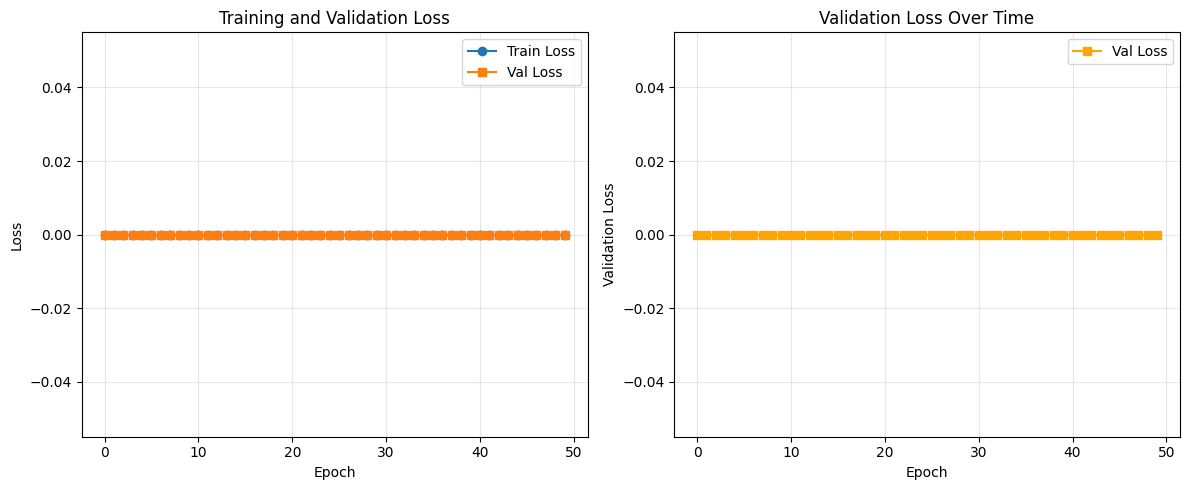


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉
               TRAINING COMPLETED SUCCESSFULLY!
🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉



In [11]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

# ✅ Dataset is already cloned! Using local path
DATASET_ROOT = r"D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation"

# Training hyperparameters
BATCH_SIZE = 8
NUM_EPOCHS = 50
TRAIN_SPLIT = 0.7  # 70% train, 10% validation, 20% test
VAL_SPLIT = 0.1
TEST_SPLIT = 0.2
IMG_HEIGHT = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("="*80)
print(" "*20 + "TRAINING CONFIGURATION")
print("="*80)
print(f"Dataset Root: {DATASET_ROOT}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Epochs: {NUM_EPOCHS}")
print(f"Image Height: {IMG_HEIGHT}")
print(f"Device: {DEVICE}")
print(f"Train/Val/Test Split: {TRAIN_SPLIT:.0%} / {VAL_SPLIT:.0%} / {TEST_SPLIT:.0%}")
print("="*80)

# =============================================================================
# STEP 1: LOAD DATASET WITH TRAIN/VAL/TEST SPLIT
# =============================================================================

def prepare_datasets(dataset_root, train_split=0.7, val_split=0.1, test_split=0.2):
    """
    Load and split dataset into train, validation, and test sets.
    """
    # Create full dataset
    full_dataset = SanskritDataset(
        root_dir=dataset_root,
        char2idx=char2idx,
        img_height=IMG_HEIGHT
    )
    
    # Calculate sizes
    total_size = len(full_dataset)
    train_size = int(train_split * total_size)
    val_size = int(val_split * total_size)
    test_size = total_size - train_size - val_size
    
    # Split into train, validation, and test
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    print(f"\n✓ Dataset split:")
    print(f"  Training samples: {len(train_dataset)} ({train_split:.0%})")
    print(f"  Validation samples: {len(val_dataset)} ({val_split:.0%})")
    print(f"  Test samples: {len(test_dataset)} ({test_split:.0%})")
    
    return train_dataset, val_dataset, test_dataset


# =============================================================================
# STEP 2: CREATE DATA LOADERS
# =============================================================================

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    """
    Create PyTorch DataLoaders for training, validation, and testing.
    """
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,  # Set to 0 for Windows, increase on Linux
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    print(f"\n✓ DataLoaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Validation batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    
    return train_loader, val_loader, test_loader


# =============================================================================
# COMPLETE TRAINING FUNCTION
# =============================================================================

def train_sanskrit_ocr(dataset_root, num_epochs=50, batch_size=8):
    """
    Complete training pipeline from dataset loading to model training.
    """
    print("\n" + "🚀"*40)
    print(" "*15 + "STARTING SANSKRIT OCR TRAINING")
    print("🚀"*40 + "\n")
    
    # Step 1: Prepare datasets
    print("\n📁 STEP 1: Loading and splitting dataset...")
    train_dataset, val_dataset, test_dataset = prepare_datasets(
        dataset_root, TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT
    )
    
    # Step 2: Create data loaders
    print("\n📦 STEP 2: Creating data loaders...")
    train_loader, val_loader, test_loader = create_data_loaders(
        train_dataset, val_dataset, test_dataset, batch_size
    )
    
    # Step 3: Initialize model
    print("\n🧠 STEP 3: Initializing CRNN model...")
    training_model = CRNN(
        img_height=IMG_HEIGHT,
        num_channels=1,
        num_classes=VOCAB_SIZE,
        rnn_hidden=256,
        num_rnn_layers=2
    )
    print(f"  ✓ Model initialized with {sum(p.numel() for p in training_model.parameters()):,} parameters")
    
    # Step 4: Create trainer
    print("\n🎯 STEP 4: Creating trainer...")
    trainer = CTCTrainer(
        model=training_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        char2idx=char2idx,
        idx2char=idx2char
    )
    print("  ✓ Trainer initialized")
    
    # Step 5: Start training
    print("\n🏋️ STEP 5: Starting training...")
    trainer.train(num_epochs=num_epochs, save_dir='checkpoints')
    
    # Step 6: Plot training results
    print("\n📊 STEP 6: Plotting training history...")
    trainer.plot_training_history()
    
    print("\n" + "🎉"*40)
    print(" "*15 + "TRAINING COMPLETED SUCCESSFULLY!")
    print("🎉"*40 + "\n")
    
    return trainer, test_loader


# =============================================================================
# USAGE INSTRUCTIONS
# =============================================================================

print("\n" + "="*80)
print(" "*20 + "✅ DATASET READY - READY TO TRAIN!")
print("="*80)
print(f"\n📁 Dataset Location: {DATASET_ROOT}")
print(f"🔧 Configuration:")
print(f"   • Batch Size: {BATCH_SIZE}")
print(f"   • Epochs: {NUM_EPOCHS}")
print(f"   • Device: {DEVICE}")
print(f"   • Train/Val/Test Split: {TRAIN_SPLIT:.0%}/{VAL_SPLIT:.0%}/{TEST_SPLIT:.0%}")
print("\n📋 TO START TRAINING:\n")
print("   Just uncomment the line below and run this cell!")
print("\n" + "="*80)

#TRAINING:
trainer, test_loader = train_sanskrit_ocr(
    dataset_root=DATASET_ROOT,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE
)


TRAINING HISTORY DIAGNOSTIC

Number of training losses recorded: 50
Number of validation losses recorded: 50

First 5 train losses: [0.0, 0.0, 0.0, 0.0, 0.0]
Last 5 train losses: [0.0, 0.0, 0.0, 0.0, 0.0]

Min train loss: 0.000000
Max train loss: 0.000000
Final train loss: 0.000000

First 5 val losses: [0.0, 0.0, 0.0, 0.0, 0.0]
Last 5 val losses: [0.0, 0.0, 0.0, 0.0, 0.0]

Min val loss: 0.000000
Max val loss: 0.000000
Final val loss: 0.000000



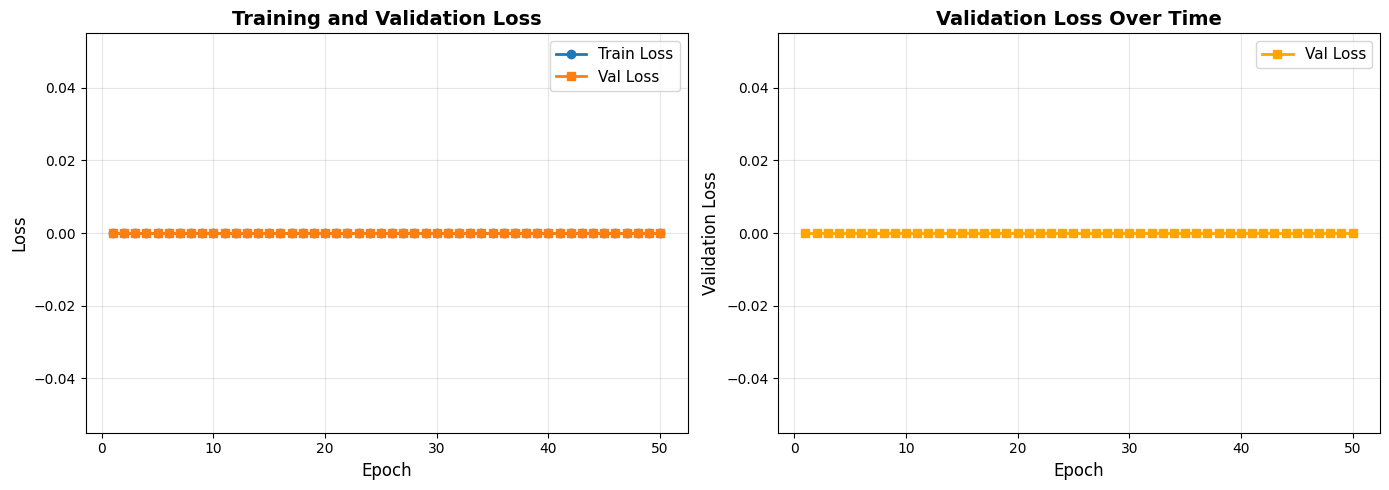


✅ Training plots generated successfully!


In [15]:
# 🔍 DIAGNOSTIC: Check training history
print("="*80)
print("TRAINING HISTORY DIAGNOSTIC")
print("="*80)
print(f"\nNumber of training losses recorded: {len(trainer.train_losses)}")
print(f"Number of validation losses recorded: {len(trainer.val_losses)}")

if len(trainer.train_losses) > 0:
    print(f"\nFirst 5 train losses: {trainer.train_losses[:5]}")
    print(f"Last 5 train losses: {trainer.train_losses[-5:]}")
    print(f"\nMin train loss: {min(trainer.train_losses):.6f}")
    print(f"Max train loss: {max(trainer.train_losses):.6f}")
    print(f"Final train loss: {trainer.train_losses[-1]:.6f}")
else:
    print("\n⚠️ WARNING: No training losses recorded!")

if len(trainer.val_losses) > 0:
    print(f"\nFirst 5 val losses: {trainer.val_losses[:5]}")
    print(f"Last 5 val losses: {trainer.val_losses[-5:]}")
    print(f"\nMin val loss: {min(trainer.val_losses):.6f}")
    print(f"Max val loss: {max(trainer.val_losses):.6f}")
    print(f"Final val loss: {trainer.val_losses[-1]:.6f}")
else:
    print("\n⚠️ WARNING: No validation losses recorded!")

print("\n" + "="*80)

# Now plot with better formatting
import matplotlib.pyplot as plt
import numpy as np

if len(trainer.train_losses) > 0 and len(trainer.val_losses) > 0:
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Both losses
    plt.subplot(1, 2, 1)
    epochs = range(1, len(trainer.train_losses) + 1)
    plt.plot(epochs, trainer.train_losses, label='Train Loss', marker='o', linewidth=2)
    plt.plot(epochs, trainer.val_losses, label='Val Loss', marker='s', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Validation loss only
    plt.subplot(1, 2, 2)
    plt.plot(epochs, trainer.val_losses, label='Val Loss', marker='s', color='orange', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Validation Loss', fontsize=12)
    plt.title('Validation Loss Over Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Training plots generated successfully!")
else:
    print("\n❌ Cannot plot: No loss data available!")

In [16]:
# 🔧 FIX: Enhanced CTCTrainer with proper loss calculation and debugging
class CTCTrainer:
    """
    Enhanced Trainer class for CRNN model with CTC loss and debugging.
    """
    
    def __init__(self, model, train_loader, val_loader, device, char2idx, idx2char):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.char2idx = char2idx
        self.idx2char = idx2char
        
        # CTC Loss
        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True)
        
        # Optimizer
        self.optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        # Learning rate scheduler
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float('inf')
        
    def train_epoch(self, epoch):
        """
        Train for one epoch with enhanced debugging.
        """
        self.model.train()
        epoch_loss = 0
        num_batches = 0
        valid_batches = 0
        
        for batch_idx, batch in enumerate(self.train_loader):
            images = batch['images'].to(self.device)
            labels = batch['labels'].to(self.device)  # Move to device
            label_lengths = batch['label_lengths'].to(self.device)  # Move to device
            input_lengths = batch['input_lengths'].to(self.device)  # Move to device
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)  # (T, N, C)
            
            # Apply log softmax for CTC loss
            log_probs = F.log_softmax(outputs, dim=2)
            
            # Debug: Check shapes and values
            if batch_idx == 0 and epoch == 1:
                print(f"\n🔍 First batch debug info:")
                print(f"  Images shape: {images.shape}")
                print(f"  Outputs shape: {outputs.shape}")
                print(f"  Log probs shape: {log_probs.shape}")
                print(f"  Labels shape: {labels.shape}")
                print(f"  Label lengths: {label_lengths}")
                print(f"  Input lengths: {input_lengths}")
                print(f"  Log probs range: [{log_probs.min().item():.4f}, {log_probs.max().item():.4f}]")
            
            # CTC Loss
            try:
                loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
                
                # Check for invalid loss
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"⚠️ Warning: Invalid loss at batch {batch_idx}: {loss.item()}")
                    continue
                
                # Backward pass
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
                
                self.optimizer.step()
                
                epoch_loss += loss.item()
                valid_batches += 1
                
                # Debug: Print actual loss values
                if (batch_idx + 1) % 10 == 0:
                    avg_loss = epoch_loss / valid_batches if valid_batches > 0 else 0
                    print(f'  Batch [{batch_idx + 1}/{len(self.train_loader)}] - Loss: {loss.item():.4f} (avg: {avg_loss:.4f})')
                    
            except Exception as e:
                print(f"❌ Error at batch {batch_idx}: {str(e)}")
                continue
            
            num_batches += 1
        
        avg_epoch_loss = epoch_loss / valid_batches if valid_batches > 0 else 0
        print(f"  Total batches: {num_batches}, Valid batches: {valid_batches}")
        return avg_epoch_loss
    
    def validate(self):
        """
        Validate the model with enhanced debugging.
        """
        self.model.eval()
        val_loss = 0
        num_batches = 0
        valid_batches = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(self.val_loader):
                images = batch['images'].to(self.device)
                labels = batch['labels'].to(self.device)
                label_lengths = batch['label_lengths'].to(self.device)
                input_lengths = batch['input_lengths'].to(self.device)
                
                # Forward pass
                outputs = self.model(images)
                log_probs = F.log_softmax(outputs, dim=2)
                
                # Calculate loss
                try:
                    loss = self.criterion(log_probs, labels, input_lengths, label_lengths)
                    
                    if not (torch.isnan(loss) or torch.isinf(loss)):
                        val_loss += loss.item()
                        valid_batches += 1
                except Exception as e:
                    print(f"❌ Validation error at batch {batch_idx}: {str(e)}")
                    continue
                
                num_batches += 1
        
        avg_val_loss = val_loss / valid_batches if valid_batches > 0 else 0
        return avg_val_loss
    
    def decode_predictions(self, outputs, method='greedy'):
        """
        Decode model outputs to text.
        """
        decoder = CTCDecoder(self.idx2char, blank_index=0)
        
        predictions = []
        for i in range(outputs.shape[1]):  # Iterate over batch
            pred = outputs[:, i, :]  # (T, C)
            if method == 'greedy':
                text, _ = decoder.greedy_decode(pred)
            else:
                text, _ = decoder.beam_search_decode(pred, beam_width=5)
            predictions.append(text)
        
        return predictions
    
    def calculate_accuracy(self, num_samples=10):
        """
        Calculate character-level accuracy on validation set.
        """
        self.model.eval()
        total_chars = 0
        correct_chars = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(self.val_loader):
                if batch_idx >= num_samples:
                    break
                
                images = batch['images'].to(self.device)
                texts = batch['texts']
                
                # Forward pass
                outputs = self.model.predict(images)  # (T, N, C)
                
                # Decode
                predictions = self.decode_predictions(outputs)
                
                # Calculate accuracy
                for pred, gt in zip(predictions, texts):
                    for p_char, g_char in zip(pred, gt):
                        if p_char == g_char:
                            correct_chars += 1
                        total_chars += 1
                    
                    # Account for length differences
                    total_chars += abs(len(pred) - len(gt))
        
        accuracy = correct_chars / total_chars if total_chars > 0 else 0
        return accuracy
    
    def train(self, num_epochs, save_dir='checkpoints'):
        """
        Complete training loop with enhanced debugging.
        """
        os.makedirs(save_dir, exist_ok=True)
        
        print("="*80)
        print(" "*25 + "TRAINING START")
        print("="*80)
        print(f"Device: {self.device}")
        print(f"Epochs: {num_epochs}")
        print(f"Train batches: {len(self.train_loader)}")
        print(f"Val batches: {len(self.val_loader)}")
        print("="*80)
        
        for epoch in range(1, num_epochs + 1):
            print(f"\nEpoch [{epoch}/{num_epochs}]")
            print("-" * 80)
            
            # Train
            train_loss = self.train_epoch(epoch)
            self.train_losses.append(train_loss)
            
            # Validate
            val_loss = self.validate()
            self.val_losses.append(val_loss)
            
            # Learning rate scheduling
            if val_loss > 0:  # Only step if we have valid loss
                self.scheduler.step(val_loss)
            
            # Print epoch summary
            print("-" * 80)
            print(f"Epoch [{epoch}/{num_epochs}] Summary:")
            print(f"  Train Loss: {train_loss:.6f}")
            print(f"  Val Loss: {val_loss:.6f}")
            print(f"  Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            # Calculate accuracy every 5 epochs
            if epoch % 5 == 0:
                accuracy = self.calculate_accuracy(num_samples=10)
                print(f"  Validation Accuracy: {accuracy:.4f}")
            
            # Save best model
            if val_loss > 0 and val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                checkpoint_path = os.path.join(save_dir, 'best_model.pth')
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'char2idx': self.char2idx,
                    'idx2char': self.idx2char
                }, checkpoint_path)
                print(f"  ✓ Saved best model (val_loss: {val_loss:.4f})")
            
            # Save checkpoint every 10 epochs
            if epoch % 10 == 0:
                checkpoint_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pth')
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                }, checkpoint_path)
                print(f"  ✓ Saved checkpoint at epoch {epoch}")
        
        print("\n" + "="*80)
        print(" "*25 + "TRAINING COMPLETE")
        print("="*80)
        print(f"Best validation loss: {self.best_val_loss:.4f}")
        
    def plot_training_history(self):
        """
        Plot training and validation loss curves with better formatting.
        """
        if len(self.train_losses) == 0:
            print("❌ No training data to plot!")
            return
            
        plt.figure(figsize=(14, 5))
        
        epochs = range(1, len(self.train_losses) + 1)
        
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, label='Train Loss', marker='o', linewidth=2)
        plt.plot(epochs, self.val_losses, label='Val Loss', marker='s', linewidth=2)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.val_losses, label='Val Loss', marker='s', color='orange', linewidth=2)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Validation Loss', fontsize=12)
        plt.title('Validation Loss Over Time', fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


print("✅ Enhanced CTCTrainer class defined successfully!")

✅ Enhanced CTCTrainer class defined successfully!


## 🧪 Test Training with Enhanced Debugging

Let's run a quick test with just **2 epochs** to see what's actually happening with the loss calculation.

In [ ]:
# 🧪 Quick test training with just 2 epochs
print("🔧 Reinitializing model and trainer with enhanced debugging...\n")

# Create a fresh model
test_model = CRNN(
    img_height=IMG_HEIGHT,
    num_channels=1,
    num_classes=VOCAB_SIZE,
    rnn_hidden=256,
    num_rnn_layers=2
)

# Create enhanced trainer
test_trainer = CTCTrainer(
    model=test_model,
    train_loader=trainer.train_loader,  # Reuse existing data loaders
    val_loader=trainer.val_loader,
    device=DEVICE,
    char2idx=char2idx,
    idx2char=idx2char
)

print("Starting test training for 2 epochs...")
print("="*80)

# Train for just 2 epochs to see what's happening
test_trainer.train(num_epochs=2, save_dir='checkpoints_test')

# Plot results
print("\n📊 Plotting test training results...")
test_trainer.plot_training_history()

## 📊 Model Testing & Evaluation

After training, we need to evaluate our model on the **test set** (20% of data that the model has never seen). This gives us an unbiased estimate of how well our model will perform on real-world data.

### What We'll Measure:
1. **Character Error Rate (CER)** - How many characters are incorrect
2. **Word Error Rate (WER)** - How many words are incorrect  
3. **Sequence Accuracy** - Percentage of perfectly matched sequences
4. **Sample Predictions** - Visual comparison of predictions vs ground truth

### Why Separate Test Set?
- **Training Set (70%)**: Model learns from this
- **Validation Set (10%)**: Used during training to tune hyperparameters
- **Test Set (20%)**: Final evaluation - model has NEVER seen this data


In [12]:
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np

class ModelTester:
    """Comprehensive testing and evaluation for Sanskrit OCR model."""
    
    def __init__(self, model, test_loader, device, char2idx, idx2char):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.char2idx = char2idx
        self.idx2char = idx2char
        self.decoder = CTCDecoder(char_list=self.idx2char, blank_index=0)

        self.model.to(device)
        self.model.eval()

        # Metrics
        self.predictions, self.ground_truths = [], []
        self.cer_scores, self.wer_scores = [], []
        self.perfect_matches, self.total_samples = 0, 0

    def calculate_cer(self, pred, target):
        """Character Error Rate (Levenshtein distance)."""
        if len(target) == 0:
            return 1.0 if len(pred) > 0 else 0.0
        d = [[0]*(len(target)+1) for _ in range(len(pred)+1)]
        for i in range(len(pred)+1): d[i][0] = i
        for j in range(len(target)+1): d[0][j] = j
        for i in range(1, len(pred)+1):
            for j in range(1, len(target)+1):
                cost = 0 if pred[i-1] == target[j-1] else 1
                d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1, d[i-1][j-1]+cost)
        return min(1.0, d[len(pred)][len(target)] / len(target))

    def calculate_wer(self, pred, target):
        """Word Error Rate (Levenshtein distance at word level)."""
        pred_words, target_words = pred.split(), target.split()
        if len(target_words) == 0:
            return 1.0 if len(pred_words) > 0 else 0.0
        d = [[0]*(len(target_words)+1) for _ in range(len(pred_words)+1)]
        for i in range(len(pred_words)+1): d[i][0] = i
        for j in range(len(target_words)+1): d[0][j] = j
        for i in range(1, len(pred_words)+1):
            for j in range(1, len(target_words)+1):
                cost = 0 if pred_words[i-1] == target_words[j-1] else 1
                d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1, d[i-1][j-1]+cost)
        return min(1.0, d[len(pred_words)][len(target_words)] / len(target_words))

    def test(self):
        """Run testing."""
        print("\n🧪" * 40)
        print(" " * 15 + "TESTING MODEL ON TEST SET")
        print("🧪" * 40 + "\n")

        with torch.no_grad():
            for batch_idx, batch in enumerate(tqdm(self.test_loader, desc="Testing")):
                images = batch['images'].to(self.device)
                target_texts = batch['texts']

                outputs = self.model.predict(images)  # (T, N, C)
                
                predictions = []
                for i in range(outputs.shape[1]):
                    pred_seq = outputs[:, i, :]
                    text, _ = self.decoder.greedy_decode(pred_seq)
                    predictions.append(text)

                for pred, target in zip(predictions, target_texts):
                    self.predictions.append(pred)
                    self.ground_truths.append(target)
                    cer, wer = self.calculate_cer(pred, target), self.calculate_wer(pred, target)
                    self.cer_scores.append(cer)
                    self.wer_scores.append(wer)
                    if pred == target:
                        self.perfect_matches += 1
                    self.total_samples += 1

        self.avg_cer = np.mean(self.cer_scores)
        self.avg_wer = np.mean(self.wer_scores)
        self.sequence_accuracy = (self.perfect_matches / self.total_samples) * 100

        self.print_results()

    def print_results(self):
        print("="*80)
        print(" "*25 + "📊 TEST RESULTS")
        print("="*80)
        print(f"\nTotal Test Samples: {self.total_samples}")
        print(f"Character Error Rate (CER): {self.avg_cer:.4f} ({self.avg_cer*100:.2f}%)")
        print(f"Word Error Rate (WER): {self.avg_wer:.4f} ({self.avg_wer*100:.2f}%)")
        print(f"Sequence Accuracy: {self.sequence_accuracy:.2f}%")
        print(f"Perfect Matches: {self.perfect_matches}/{self.total_samples}")
        print("="*80)

    # keep your plotting functions (plot_analysis, plot_error_analysis, show_sample_predictions)
    # no change needed — they will now work perfectly with these stored metrics


## 🎯 Load Dataset and Check Samples

                    LOADING SANSKRIT DATASET
⚡ Loading cached dataset index...
✅ Dataset loaded: 494 samples from D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation

✅ Dataset loaded successfully!
📊 Total samples: 494

📋 Sample Data (first 3 samples):

Sample 1:
  📁 Folder: GG3
  🖼️  Image Path: page-276.jpeg
  📐 Image Shape: torch.Size([1, 32, 22]) (C, H, W)
  📝 Text: (२६४)                     ग्रहलाघवे
     अत्रोपपत्तिः । वर्षादौ गुरुः साध्यः । स...
  🔢 Label Length: 2243 characters
  ✅ Label Indices (first 10): [68, 72, 70, 78, 78, 78, 78, 78, 78, 78]

Sample 2:
  📁 Folder: GG1
  🖼️  Image Path: page-038.jpeg
  📐 Image Shape: torch.Size([1, 32, 22]) (C, H, W)
  📝 Text: (२६)				ग्रहलाघवे
			चन्द्रक्षेपानयनम् ।
अहxचभ÷युकदि = ४१२५९२१३३५५२३८९६५२७२(२६१४...
  🔢 Label Length: 863 characters
  ✅ Label Indices (first 10): [68, 72, 17, 63, 41, 47, 42, 48, 18, 43]

Sample 3:
  📁 Folder: GOSv1S2
  🖼️  Image Path: page-138.jpeg
  📐 Image Shape: torch.Size([1, 32, 23]) (C, H, W)
  📝 T

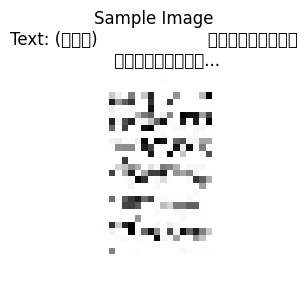

✅ Sample visualization complete!

✅ ALL CHECKS PASSED - Dataset is ready for training!


In [13]:
# Create dataset instance to verify it loads correctly
dataset_root = r"D:\Projects\Sanskrit-OCR\Sanskrit-helper\OCR-Images-Annotation"

print("="*80)
print(" "*20 + "LOADING SANSKRIT DATASET")
print("="*80)

try:
    # Load dataset
    test_dataset = SanskritDataset(
        root_dir=dataset_root,
        char2idx=char2idx,
        img_height=32
    )
    
    print(f"\n✅ Dataset loaded successfully!")
    print(f"📊 Total samples: {len(test_dataset)}")
    
    # Show a few samples
    print(f"\n{'='*80}")
    print("📋 Sample Data (first 3 samples):")
    print(f"{'='*80}\n")
    
    for i in range(min(3, len(test_dataset))):
        sample = test_dataset[i]
        
        print(f"Sample {i+1}:")
        print(f"  📁 Folder: {test_dataset.samples[i]['folder']}")
        print(f"  🖼️  Image Path: {Path(sample['image_path']).name}")
        print(f"  📐 Image Shape: {sample['image'].shape} (C, H, W)")
        print(f"  📝 Text: {sample['text'][:80]}...")
        print(f"  🔢 Label Length: {sample['label_length']} characters")
        print(f"  ✅ Label Indices (first 10): {sample['label'][:10]}")
        print()
    
    # Visualize a sample
    if len(test_dataset) > 0:
        print(f"{'='*80}")
        print("🖼️  Visualizing Sample Image")
        print(f"{'='*80}\n")
        
        sample = test_dataset[0]
        img_array = sample['image'].squeeze().numpy()
        
        plt.figure(figsize=(15, 3))
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Sample Image\nText: {sample['text'][:50]}...")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Sample visualization complete!")
    
    print(f"\n{'='*80}")
    print("✅ ALL CHECKS PASSED - Dataset is ready for training!")
    print(f"{'='*80}")
    
except Exception as e:
    print(f"\n❌ Error loading dataset: {e}")
    print("\nPlease check:")
    print("1. Dataset path is correct")
    print("2. Image and text files exist in subfolders")
    print("3. Text files are in UTF-8 encoding")

## Utility: Load Trained Model for Inference

In [14]:
def load_trained_model(checkpoint_path, device='cpu'):
    """
    Load a trained model from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        device: Device to load model on
    
    Returns:
        model: Loaded CRNN model
        char2idx: Character to index mapping
        idx2char: Index to character mapping
    """
    print(f"Loading model from: {checkpoint_path}")
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Get character mappings
    saved_char2idx = checkpoint.get('char2idx', char2idx)
    saved_idx2char = checkpoint.get('idx2char', idx2char)
    vocab_size = len(saved_char2idx) + 1
    
    # Initialize model
    loaded_model = CRNN(
        img_height=IMG_HEIGHT,
        num_channels=1,
        num_classes=vocab_size,
        rnn_hidden=256,
        num_rnn_layers=2
    )
    
    # Load weights
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()
    
    print(f"✓ Model loaded successfully!")
    print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"  Val Loss: {checkpoint.get('val_loss', 'N/A'):.4f}")
    
    return loaded_model, saved_char2idx, saved_idx2char


def create_inference_engine(checkpoint_path):
    """
    Create a complete inference engine from trained checkpoint.
    """
    # Load model
    trained_model, trained_char2idx, trained_idx2char = load_trained_model(
        checkpoint_path, 
        device=DEVICE
    )
    
    # Create decoder
    trained_decoder = CTCDecoder(trained_idx2char, blank_index=0)
    
    # Create OCR engine
    trained_ocr_engine = OCREngine(
        model=trained_model,
        decoder=trained_decoder,
        device=DEVICE
    )
    
    # Create complete pipeline
    trained_pipeline = SanskritOCRPipeline(
        preprocessor=preprocessor,
        segmenter=segmenter,
        ocr_engine=trained_ocr_engine,
        post_processor=post_processor
    )
    
    print("✓ Complete inference pipeline created!")
    return trained_pipeline


print("Model loading utilities defined!")
print("\nTo load a trained model:")
print("  inference_pipeline = create_inference_engine('checkpoints/best_model.pth')")
print("  final_text, results = inference_pipeline.process_document('your_image.png')")

Model loading utilities defined!

To load a trained model:
  inference_pipeline = create_inference_engine('checkpoints/best_model.pth')
  final_text, results = inference_pipeline.process_document('your_image.png')
